# St Helens Creek — SAC-SMA Calibration with ARIES (Student-t Likelihood)

Ensemble-based Bayesian inference using the **adaptive Student-t likelihood**
in ARIES. Each observation gets a latent weight $\lambda_i$ that down-weights
outliers; the degrees of freedom $\nu$ is estimated from ensemble residuals
at each iteration.

**Catchment area:** 120.5 km²  |  **Gauge period:** 1979–2018  |  **Timestep:** daily

### Workbook overview
1. Define calibration/validation split
2. Run **ARIES with adaptive Student-t likelihood** on training data
3. Track $\nu$ convergence across iterations
4. Plot **posterior marginals** for all 14 parameters
5. Compute **posterior predictive** and 95% credible intervals
6. Calculate **performance statistics** (NSE, PBIAS, R², P-factor, R-factor)

In [1]:
import sys, os, glob, warnings
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from joblib import Parallel, delayed

import matplotlib.pyplot as plt

from aries import esmda
from sacramento import sacsma

warnings.filterwarnings("ignore")

## 1. Calibration / Validation Split

Change `SPLIT_DATE` to move the split point.

In [2]:
SPLIT_DATE = "2010-01-01"  # ← CHANGE THIS

MODEL_DATE_RANGE = pd.date_range(start="1973-02-08", end="2018-12-31")
GAUGE_START = "1979-01-01"
GAUGE_END   = "2018-12-31"
CATCHMENT_AREA = 120_500_000.0
LAM = 0.5

all_obs_dates = pd.date_range(GAUGE_START, GAUGE_END)
train_mask = all_obs_dates < pd.Timestamp(SPLIT_DATE)
val_mask   = all_obs_dates >= pd.Timestamp(SPLIT_DATE)
train_dates = all_obs_dates[train_mask]
val_dates   = all_obs_dates[val_mask]

print(f"Total gauge period:   {GAUGE_START} → {GAUGE_END}  ({len(all_obs_dates):,} days)")
print(f"Training period:      {train_dates[0].date()} → {train_dates[-1].date()}  ({len(train_dates):,} days)")
print(f"Validation period:    {val_dates[0].date()} → {val_dates[-1].date()}  ({len(val_dates):,} days)")

Total gauge period:   1979-01-01 → 2018-12-31  (14,610 days)
Training period:      1979-01-01 → 2009-12-31  (11,323 days)
Validation period:    2010-01-01 → 2018-12-31  (3,287 days)


In [3]:
forcing = pd.read_csv("data/st_helens_forcing_original.csv")
forcing["date"] = pd.to_datetime(forcing["date"], dayfirst=True)
forcing = forcing.set_index("date")

# Gauge-period observations
forcing["in_gauge"] = (forcing.index >= GAUGE_START) & (forcing.index <= GAUGE_END)
gauge_data = forcing[forcing["in_gauge"]].copy()

Y_obs_cumecs_all = gauge_data["Q_CUMEC"].values
Y_obs_trans_all  = np.clip(Y_obs_cumecs_all, 0, None) ** LAM

Y_obs_cumecs_train = Y_obs_cumecs_all[train_mask]
Y_obs_cumecs_val   = Y_obs_cumecs_all[val_mask]
Y_obs_trans_train  = Y_obs_trans_all[train_mask]
Y_obs_trans_val    = Y_obs_trans_all[val_mask]

print(f"Training obs:   {len(Y_obs_trans_train):,} days  (mean={Y_obs_cumecs_train.mean():.2f} cumecs)")
print(f"Validation obs: {len(Y_obs_trans_val):,} days  (mean={Y_obs_cumecs_val.mean():.2f} cumecs)")

Training obs:   11,323 days  (mean=3.94 cumecs)
Validation obs: 3,287 days  (mean=4.73 cumecs)


In [4]:
# Build observation CSV (training period only)
obs_rows = []
for i, d in enumerate(train_dates):
    obs_rows.append({
        "label": d.strftime("%d/%m/%Y"),
        "group": "FLOW",
        "Y": Y_obs_trans_train[i],
    })
obs_df = pd.DataFrame(obs_rows)
obs_path = "data/es_data_train.csv"
obs_df.to_csv(obs_path, index=False)
print(f"Wrote {obs_path}  ({len(obs_df):,} rows)")

Wrote data/es_data_train.csv  (11,323 rows)


## 2. Forward Model

In [5]:
Precipitation = forcing["rainfall"].values
Evaporation   = forcing["pet"].values

def run_model(parameter_set, return_raw_cumecs=False):
    result = sacsma(Precipitation, Evaporation, np.asarray(parameter_set, float))
    result = result * CATCHMENT_AREA / 1000
    result = result / (3600 * 24)
    df = pd.DataFrame({"data": result}, index=MODEL_DATE_RANGE)
    df = df[(df.index >= GAUGE_START) & (df.index <= GAUGE_END)]
    vals = df["data"].values.copy()
    if return_raw_cumecs:
        return vals
    else:
        return np.clip(vals, 0, None) ** LAM


def run_model_train(parameter_set):
    """Training-period predictions only — must match observation CSV rows."""
    full = run_model(parameter_set)
    return full[train_mask]

NUM_PROCESSES = 4

def fill_ensemble(m, nEnsemble, mLength, dLength):
    y = np.zeros([dLength, nEnsemble])
    delayed_funcs = [delayed(run_model_train)(m[:, j]) for j in range(nEnsemble)]
    model_results = Parallel(n_jobs=NUM_PROCESSES, verbose=1,
                              backend="threading")(delayed_funcs)
    for j in range(nEnsemble):
        y[:, j] = model_results[j]
    return y

# Sanity check
test_params = np.array([47.5, 42.5, 160, 320, 157.5, 0.1, 0.55,
                        0.0155, 0.415, 40, 2.5, 0.025, 0.4, 0.4])
test_out = run_model_train(test_params)
print(f"Sanity: train-only output shape={test_out.shape} (obs CSV rows: {len(obs_df):,})")

Sanity: train-only output shape=(11323,) (obs CSV rows: 11,323)


## 3. Run ARIES with Adaptive Student-t Likelihood

Key settings:
- **1,000 ensemble members × 12 iterations**
- **eFAST subspace inversion**
- **IKEA adaptive noise covariance**
- **Student-t likelihood** with ν = 8 (initial), adapted from residuals each iteration

In [6]:
error = {"FLOW": 10.0}

solver = esmda(
    parameter_file_name="data/es_parameters.csv",
    observation_file_name="data/es_data_train.csv",
    nEnsemble=1000,
    maxIter=12,
    error=error,
    job_name="aries_student_t_output",
    inversion_type="efast_subspace",
    calculation_type="ikea",
    phi_update="laplace",
    inflation_schedule="fixed",
    # ── Student-t likelihood (these are new) ──
    likelihood="student_t",
    nu_init=8.0,
    nu_adapt=True,
    nu_smooth=0.7,
)

solver.run_esmda(fill_ensemble)

Deleting directory aries_student_t_output
   parameter   lower   upper      mean  width  length       model        type  \
0      Uztwm  30.000  125.00   47.5000      4       0  sacramento       store   
1      Uzfwm  10.000   75.00   42.5000      4       0  sacramento       store   
2      Lztwm  20.000  300.00  160.0000      4       0  sacramento       store   
3      Lzfpm  40.000  600.00  320.0000      4       0  sacramento       store   
4      Lzfsm  15.000  300.00  157.5000      4       0  sacramento       store   
5      Adimp   0.000    0.20    0.1000      4       0  sacramento  impervious   
6        Uzk   0.200    0.90    0.5500      4       0  sacramento        rate   
7       Lzpk   0.001    0.03    0.0155      4       0  sacramento        rate   
8       Lzsk   0.030    0.80    0.4150      4       0  sacramento        rate   
9      Zperc   0.000   80.00   40.0000      4       0  sacramento   percolate   
10      Rexp   0.000    5.00    2.5000      4       0  sacramento  

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   42 out of 1000 | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done  192 out of 1000 | elapsed:    2.5s
[Parallel(n_jobs=4)]: Done  442 out of 1000 | elapsed:    3.9s
[Parallel(n_jobs=4)]: Done  792 out of 1000 | elapsed:    6.0s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:    7.3s finished



═══ Iteration 1/12 ═══
  Params: 56.7997  42.2258  157.8016  317.2084  154.0967  0.1001  … (14 params)
  Inversion: efast_subspace
  Time: 9.70s
  φ = 0.7368
  ν = 8.0


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   42 out of 1000 | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done  192 out of 1000 | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done  442 out of 1000 | elapsed:    2.8s
[Parallel(n_jobs=4)]: Done  792 out of 1000 | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:    6.4s finished



═══ Iteration 2/12 ═══
  Params: 54.8214  43.8614  133.1995  257.3135  148.7917  0.1114  … (14 params)
  Inversion: efast_subspace
  Time: 11.38s
  φ = 0.7034
  ν = 6.9


...


═══ Iteration 10/12 ═══
  Params: 31.5480  48.5411  85.0166  140.3293  78.8535  0.0374  … (14 params)
  Inversion: efast_subspace
  Time: 10.02s
  φ = 0.5446
  ν = 4.4


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   42 out of 1000 | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done  192 out of 1000 | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  442 out of 1000 | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done  792 out of 1000 | elapsed:    4.8s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:    6.0s finished



═══ Iteration 11/12 ═══
  Params: 31.4123  48.3340  85.0576  141.2888  77.2586  0.0369  … (14 params)
  Inversion: efast_subspace
  Time: 8.44s
  φ = 0.5443
  ν = 4.4


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   42 out of 1000 | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done  192 out of 1000 | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  442 out of 1000 | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done  792 out of 1000 | elapsed:    4.8s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:    6.2s finished



═══ Iteration 12/12 ═══
 
Completed iteration  11
 


### 3a. ν Convergence

Extract the per-iteration ν estimates from the ARIES output.

In [7]:
# ARIES stores the final ν in solver._nu after the run
final_nu = solver._nu
print(f"Final ν (degrees of freedom): {final_nu:.1f}")
if final_nu < 10:
    print("  → Strongly heavy-tailed: data strongly prefer robust likelihood")
elif final_nu < 30:
    print("  → Moderately heavy-tailed: some outlier down-weighting")
else:
    print("  → Near-Gaussian: data do not require heavy tails")

Final ν (degrees of freedom): 4.3
  → Strongly heavy-tailed: data strongly prefer robust likelihood


## 4. Load ARIES Posterior

In [8]:
param_files = sorted(glob.glob("aries_student_t_output/*_parameters.csv"))
if not param_files:
    param_files = sorted(glob.glob("aries_student_t_output/*final*parameters*"))
posterior_file = param_files[-1]
print(f"Loading posterior from: {posterior_file}")

aries_posterior = pd.read_csv(posterior_file, index_col=0)
aries_posterior = aries_posterior.T.astype(float)
aries_posterior.columns = aries_posterior.columns.str.strip()

param_names = list(aries_posterior.columns)
n_ensemble  = len(aries_posterior)
print(f"Posterior ensemble: {n_ensemble} members × {len(param_names)} parameters")
aries_posterior.describe()

Loading posterior from: aries_student_t_output/aries_student_t_output_11_parameters.csv
Posterior ensemble: 1000 members × 14 parameters


,Uztwm,Uzfwm,Lztwm,Lzfpm,Lzfsm,Adimp,Uzk,Lzpk,Lzsk,Zperc,Rexp,Pctim,Pfree,Side
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.298667,47.801621,85.411927,141.288331,76.248571,0.037030,0.831276,0.021168,0.343098,45.768498,3.955736,0.004940,0.336889,0.107853
std,0.501848,2.909417,4.844589,7.135958,6.209691,0.011852,0.015307,0.000659,0.015297,7.723782,0.373300,0.001059,0.017474,0.024085
min,30.006685,37.869404,70.971298,105.800174,50.842651,0.003977,0.782538,0.018467,0.254310,25.745753,2.580105,0.001300,0.187695,0.015475
25%,30.964042,45.803583,82.348368,136.417452,71.808003,0.028627,0.822081,0.020758,0.332507,40.544929,3.684312,0.004247,0.326007,0.092250
50%,31.255917,47.808270,85.235874,141.255808,76.198983,0.036554,0.832152,0.021182,0.343265,45.208601,3.962935,0.004918,0.336859,0.106964
75%,31.602620,49.703593,88.296487,146.195858,80.470216,0.045219,0.840997,0.021603,0.353270,50.052311,4.218443,0.005660,0.348581,0.123588
max,33.285034,64.588579,135.500066,162.457762,104.908569,0.093114,0.892886,0.024827,0.400324,76.493686,4.924797,0.008743,0.390667,0.196998


## 5. Posterior Marginals

Kernel density estimates for all 14 SAC-SMA parameters with prior bounds.

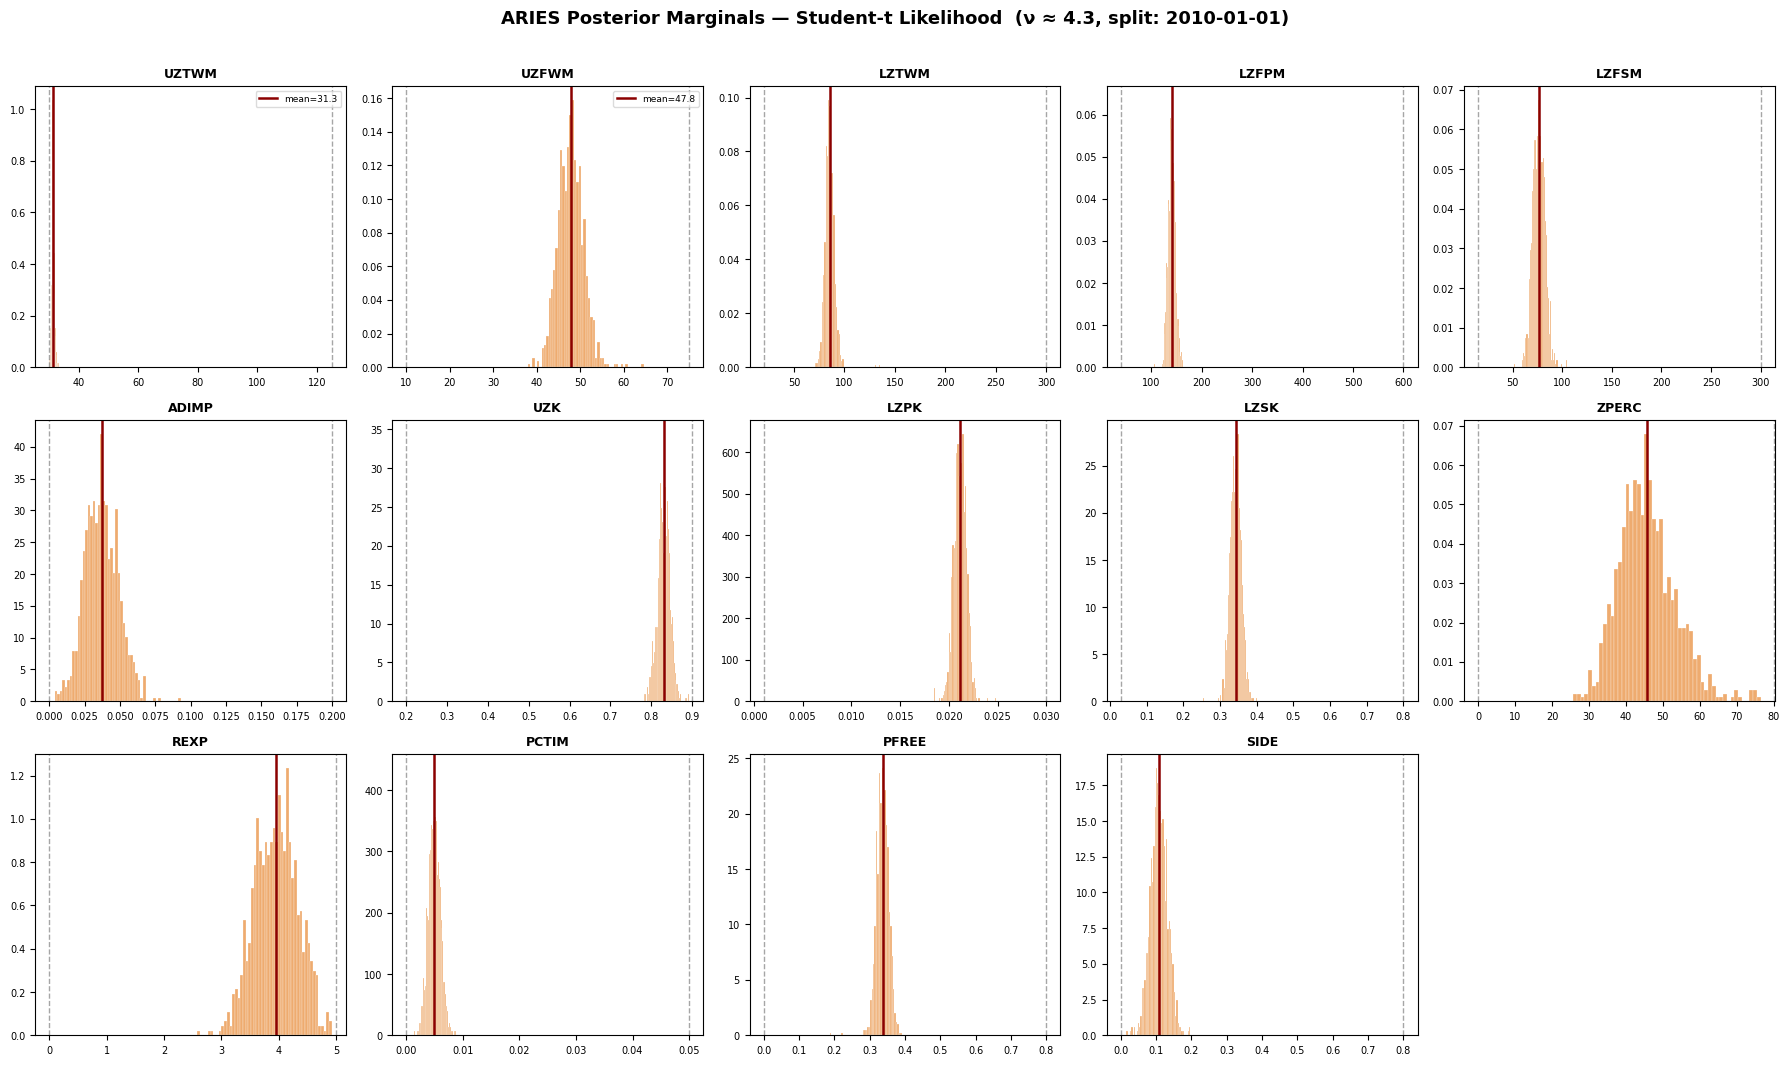

In [9]:
prior_info = pd.read_csv("data/es_parameters.csv")

n_params = len(param_names)
n_cols = 5
n_rows = int(np.ceil(n_params / n_cols))

param_display = {
    "Uztwm": "UZTWM", "Uzfwm": "UZFWM", "Lztwm": "LZTWM",
    "Lzfpm": "LZFPM", "Lzfsm": "LZFSM", "Adimp": "ADIMP",
    "Uzk": "UZK", "Lzpk": "LZPK", "Lzsk": "LZSK",
    "Zperc": "ZPERC", "Rexp": "REXP", "Pctim": "PCTIM",
    "Pfree": "PFREE", "Side": "SIDE",
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(param_names, axes)):
    samples = aries_posterior[name].values
    prior_row = prior_info[prior_info["parameter"] == name]
    lo = prior_row["lower"].values[0]
    hi = prior_row["upper"].values[0]

    ax.hist(samples, bins=50, density=True, alpha=0.65,
            color="#E67E22", edgecolor="white", linewidth=0.3)
    ax.axvline(samples.mean(), color="darkred", lw=1.8,
               label=f"mean={samples.mean():.4g}")
    ax.axvline(lo, color="gray", ls="--", lw=1.0, alpha=0.7)
    ax.axvline(hi, color="gray", ls="--", lw=1.0, alpha=0.7)

    ax.set_title(param_display.get(name, name), fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    if i < 2:
        ax.legend(fontsize=6.5, loc="upper right", framealpha=0.7)

# Hide unused
for ax in axes[n_params:]:
    ax.set_visible(False)

fig.suptitle(f"ARIES Posterior Marginals — Student-t Likelihood  (ν ≈ {final_nu:.1f}, split: {SPLIT_DATE})",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 6. Posterior Predictive

Run forward model for all posterior members, add Student-t noise in
transformed space, back-transform to cumecs.

In [10]:
post_params = aries_posterior[param_names].values.astype(float)

print(f"Running {n_ensemble} forward runs...")
all_preds_raw = np.array(
    Parallel(n_jobs=NUM_PROCESSES, verbose=1, backend="threading")(
        delayed(run_model)(post_params[j], return_raw_cumecs=True)
        for j in range(n_ensemble)
    )
)
all_preds_trans = np.clip(all_preds_raw, 0, None) ** LAM

preds_train_t = all_preds_trans[:, train_mask]
preds_val_t   = all_preds_trans[:, val_mask]

# Estimate residual noise in transformed space
train_mean_pred_t = preds_train_t.mean(axis=0)
train_residuals_t = Y_obs_trans_train - train_mean_pred_t
noise_std_trans = np.std(train_residuals_t)
print(f"Residual noise σ (transformed): {noise_std_trans:.3f}")

Running 1000 forward runs...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    4.7s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:    6.0s finished


Residual noise σ (transformed): 0.542


In [11]:
# Construct PPC with Student-t noise
rng = np.random.default_rng(42)
n_ppc = min(500, n_ensemble)
ppc_idx = rng.choice(n_ensemble, size=n_ppc, replace=False)

def make_ppc_student_t(det_preds_trans):
    """Add Student-t noise in transformed space, back-transform to cumecs."""
    ppc_t = np.clip(det_preds_trans[ppc_idx], 0, None)
    # Student-t noise with ν from ARIES
    noise = rng.standard_t(df=max(final_nu, 2.1), size=ppc_t.shape) * noise_std_trans
    ppc_noisy_t = np.clip(ppc_t + noise, 0, None)
    return ppc_noisy_t ** (1.0 / LAM)

ppc_train = make_ppc_student_t(preds_train_t)
ppc_val   = make_ppc_student_t(preds_val_t)

ppc_train_mean = ppc_train.mean(axis=0)
ppc_train_lo   = np.percentile(ppc_train, 2.5, axis=0)
ppc_train_hi   = np.percentile(ppc_train, 97.5, axis=0)
ppc_val_mean   = ppc_val.mean(axis=0)
ppc_val_lo     = np.percentile(ppc_val, 2.5, axis=0)
ppc_val_hi     = np.percentile(ppc_val, 97.5, axis=0)

print(f"Train mean predictive: {ppc_train_mean.mean():.2f} cumecs  (obs: {Y_obs_cumecs_train.mean():.2f})")
print(f"Val   mean predictive: {ppc_val_mean.mean():.2f} cumecs  (obs: {Y_obs_cumecs_val.mean():.2f})")

Train mean predictive: 3.83 cumecs  (obs: 3.94)
Val   mean predictive: 5.19 cumecs  (obs: 4.73)


### 6a. PPC Time Series

First 3 years of the training period.

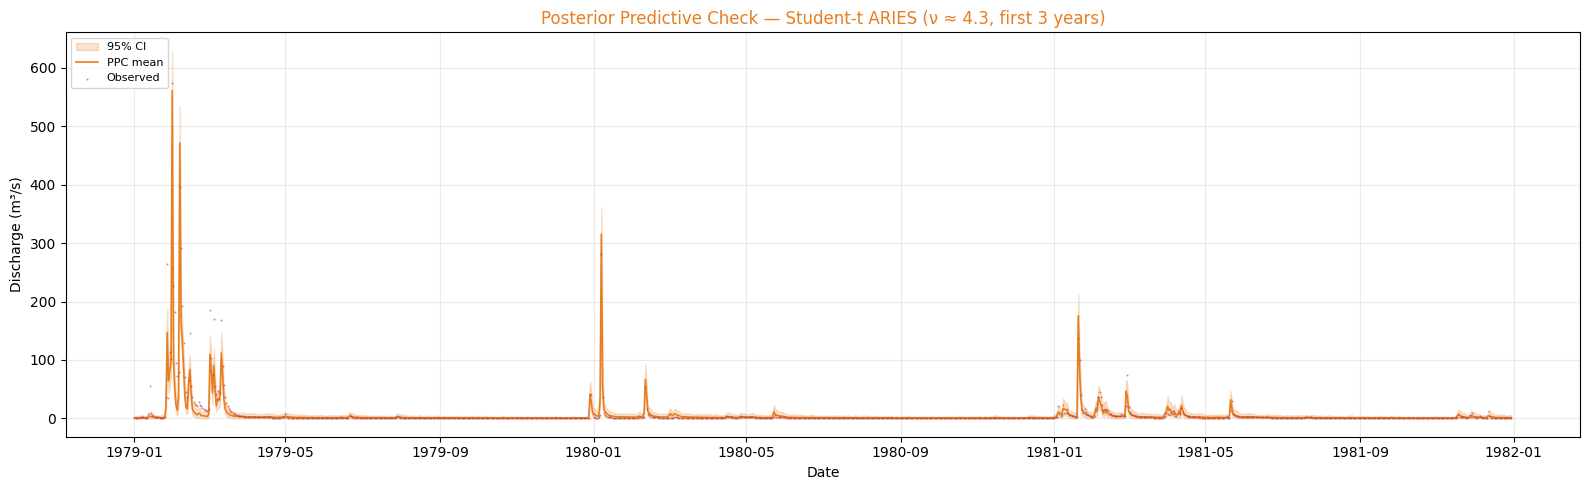

In [12]:
Y_obs_cumecs = Y_obs_cumecs_all

WINDOW = 365 * 3
d = all_obs_dates[:WINDOW]

# Build full-length arrays for plotting
full_mean = np.full(len(all_obs_dates), np.nan)
full_mean[train_mask] = ppc_train_mean
full_mean[val_mask]   = ppc_val_mean
full_lo = np.full(len(all_obs_dates), np.nan)
full_lo[train_mask] = ppc_train_lo
full_lo[val_mask]   = ppc_val_lo
full_hi = np.full(len(all_obs_dates), np.nan)
full_hi[train_mask] = ppc_train_hi
full_hi[val_mask]   = ppc_val_hi

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(d, full_lo[:WINDOW], full_hi[:WINDOW],
                color="#E67E22", alpha=0.22, label="95% CI")
ax.plot(d, full_mean[:WINDOW], color="#E67E22", lw=1.2, label="PPC mean")
ax.scatter(d, Y_obs_cumecs[:WINDOW], c="#C0392B", s=2, alpha=0.6,
           linewidths=0, label="Observed", zorder=10)

ax.set_ylabel("Discharge (m³/s)")
ax.set_xlabel("Date")
ax.set_title(f"Posterior Predictive Check — Student-t ARIES (ν ≈ {final_nu:.1f}, first 3 years)",
             fontsize=12, color="#E67E22")
ax.legend(fontsize=8, loc="upper left", framealpha=0.8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Performance Statistics

Metrics in original cumecs units for training and validation.

In [13]:
def compute_metrics(y_obs, ppc_mean, ppc_lo, ppc_hi):
    """Compute hydrological performance metrics."""
    nse = 1.0 - np.sum((y_obs - ppc_mean)**2) / np.sum((y_obs - y_obs.mean())**2)
    pbias = 100.0 * np.sum(ppc_mean - y_obs) / np.sum(y_obs)
    r, _ = pearsonr(ppc_mean, y_obs)
    r2 = r ** 2
    in_ci = (y_obs >= ppc_lo) & (y_obs <= ppc_hi)
    p_factor = in_ci.mean() * 100
    r_factor = (ppc_hi - ppc_lo).mean() / y_obs.std()
    return {"NSE": nse, "PBIAS": pbias, "R2": r2,
            "P_factor": p_factor, "R_factor": r_factor}

metrics_train = compute_metrics(Y_obs_cumecs_train, ppc_train_mean, ppc_train_lo, ppc_train_hi)
metrics_val   = compute_metrics(Y_obs_cumecs_val,   ppc_val_mean,   ppc_val_lo,   ppc_val_hi)

print("═" * 62)
print(f"  Performance Summary  (Student-t ARIES, ν ≈ {final_nu:.1f}, split: {SPLIT_DATE})")
print("═" * 62)
print(f"  {'Metric':<18s} {'Training':>12s} {'Validation':>12s} {'Δ':>12s}")
print(f"  {'─'*18} {'─'*12} {'─'*12} {'─'*12}")
for key, label in [("NSE", "NSE"), ("PBIAS", "PBIAS (%)"),
                     ("R2", "R²"), ("P_factor", "P-factor (%)"),
                     ("R_factor", "R-factor")]:
    t = metrics_train[key]
    v = metrics_val[key]
    print(f"  {label:<18s} {t:>12.4f} {v:>12.4f} {v-t:>+12.4f}")
print(f"\n  Noise σ (transformed): {noise_std_trans:.4f}")
print("═" * 62)

══════════════════════════════════════════════════════════════
  Performance Summary  (Student-t ARIES, ν ≈ 4.3, split: 2010-01-01)
══════════════════════════════════════════════════════════════
  Metric                 Training   Validation            Δ
  ────────────────── ──────────── ──────────── ────────────
  NSE                      0.8575       0.8497      -0.0078
  PBIAS (%)               -2.8180       9.7029     +12.5209
  R²                       0.8621       0.8571      -0.0050
  P-factor (%)            97.4388      96.7448      -0.6941
  R-factor                 0.3360       0.3990      +0.0630

  Noise σ (transformed): 0.5424
══════════════════════════════════════════════════════════════


In [14]:
# ── Summary ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  STUDENT-T ARIES — CALIBRATION SUMMARY")
print("═" * 60)
print(f"  Likelihood:          Student-t (ν ≈ {final_nu:.1f}, adaptive)")
print(f"  Ensemble:            1,000 members × 12 iterations")
print(f"  Calibration period:  {train_dates[0].date()} → {train_dates[-1].date()}  ({len(train_dates):,} days)")
print(f"  Validation period:   {val_dates[0].date()} → {val_dates[-1].date()}  ({len(val_dates):,} days)")
print(f"  Split date:          {SPLIT_DATE}")
print("─" * 60)
print(f"  Training NSE:        {metrics_train['NSE']:.4f}")
print(f"  Validation NSE:      {metrics_val['NSE']:.4f}")
print(f"  Training PBIAS:      {metrics_train['PBIAS']:+.2f}%")
print(f"  Validation PBIAS:    {metrics_val['PBIAS']:+.2f}%")
print(f"  Training R²:         {metrics_train['R2']:.4f}")
print(f"  Validation R²:       {metrics_val['R2']:.4f}")
print(f"  Training P-factor:   {metrics_train['P_factor']:.1f}%")
print(f"  Validation P-factor: {metrics_val['P_factor']:.1f}%")
print(f"  Training R-factor:   {metrics_train['R_factor']:.4f}")
print(f"  Validation R-factor: {metrics_val['R_factor']:.4f}")
print(f"  Noise σ (trans):     {noise_std_trans:.4f}")
print("═" * 60)
print("\nTo change the split date, modify SPLIT_DATE in Cell 3 and re-run.")


════════════════════════════════════════════════════════════
  STUDENT-T ARIES — CALIBRATION SUMMARY
════════════════════════════════════════════════════════════
  Likelihood:          Student-t (ν ≈ 4.3, adaptive)
  Ensemble:            1,000 members × 12 iterations
  Calibration period:  1979-01-01 → 2009-12-31  (11,323 days)
  Validation period:   2010-01-01 → 2018-12-31  (3,287 days)
  Split date:          2010-01-01
────────────────────────────────────────────────────────────
  Training NSE:        0.8575
  Validation NSE:      0.8497
  Training PBIAS:      -2.82%
  Validation PBIAS:    +9.70%
  Training R²:         0.8621
  Validation R²:       0.8571
  Training P-factor:   97.4%
  Validation P-factor: 96.7%
  Training R-factor:   0.3360
  Validation R-factor: 0.3990
  Noise σ (trans):     0.5424
════════════════════════════════════════════════════════════

To change the split date, modify SPLIT_DATE in Cell 3 and re-run.
